# **EXTRACTION**

Konsep ekstraksi LSB itu kebalikan tepat dari embedding: kalau saat embed kamu mengeluarkan LSB<br> dan menaruhnya di sana, saat ekstraksi kamu tinggal membaca kembali LSB itu dari posisi dan channel yang <br>sama persis. Karena pakai skema single channel Blue, ekstraksi juga wajib dari channel Blue,<br> bukan sembarang channel. kalau salah channel, hasilnya pasti rusak/random.

In [29]:
# Library
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# --- Baca gambar watermarked (hasil embedding) ---
watermarked_small  = cv2.imread("../data/watermarked/watermarked_small.png")
watermarked_medium = cv2.imread("../data/watermarked/watermarked_medium.png")
watermarked_high   = cv2.imread("../data/watermarked/watermarked_high.png")

for name, img in [("small", watermarked_small), ("medium", watermarked_medium), ("high", watermarked_high)]:
    if img is None:
        raise FileNotFoundError(f"Gambar watermarked '{name}' tidak ditemukan atau gagal dibaca")

# --- Baca watermark ASLI (hasil resize+threshold, sebelum di-embed) ---
# dipindah ke atas, karena h,w dan verifikasi butuh ini duluan
logo1_small_bw  = cv2.imread("../data/resize/resize_small_payload.png", 0)
logo2_medium_bw = cv2.imread("../data/resize/resize_medium_payload.png", 0)
logo3_high_bw   = cv2.imread("../data/resize/resize_high_payload.png", 0)

for name, img in [("small", logo1_small_bw), ("medium", logo2_medium_bw), ("high", logo3_high_bw)]:
    if img is None:
        raise FileNotFoundError(f"Watermark asli '{name}' tidak ditemukan atau gagal dibaca")

watermark1_bit_original = logo1_small_bw // 255
watermark2_bit_original = logo2_medium_bw // 255
watermark3_bit_original = logo3_high_bw // 255


In [31]:
# --- Proses Ekstraksi - LSB ---
'''
Ekstrak watermark dari LSB salah satu channel warna watermarked_img.
    channel: 0 = Blue, 1 = Green, 2 = Red (urutan OpenCV/BGR).
    HARUS SAMA dengan channel yang dipakai saat embedding.

    Mengembalikan:
    - extracted_bit  : array 0/1, untuk dibandingkan dengan watermark asli
    - extracted_bw   : array 0/255, untuk ditampilkan sebagai gambar
'''
def extract_lsb(watermarked_img, h, w, channel=0):
    assert watermarked_img.ndim == 3, "watermarked_img harus gambar berwarna (3 channel)"

    region = watermarked_img[0:h, 0:w, channel]

    # ambil lsb dengan bitwise AND 1 (00000001)
    extracted_bit = region & 1

    # ubah ke 0/255 supaya bisa ditampilkan sebagai gambar hitam-putih
    extracted_bw = extracted_bit * 255

    return extracted_bit, extracted_bw

# ambil ukuran otomatis dari watermark ASLI (sekarang sudah pasti ada)
h1, w1 = logo1_small_bw.shape
h2, w2 = logo2_medium_bw.shape
h3, w3 = logo3_high_bw.shape

extracted_small_bit,  extracted_small_bw  = extract_lsb(watermarked_small,  h1, w1, channel=0)
extracted_medium_bit, extracted_medium_bw = extract_lsb(watermarked_medium, h2, w2, channel=0)
extracted_high_bit,   extracted_high_bw   = extract_lsb(watermarked_high,   h3, w3, channel=0)



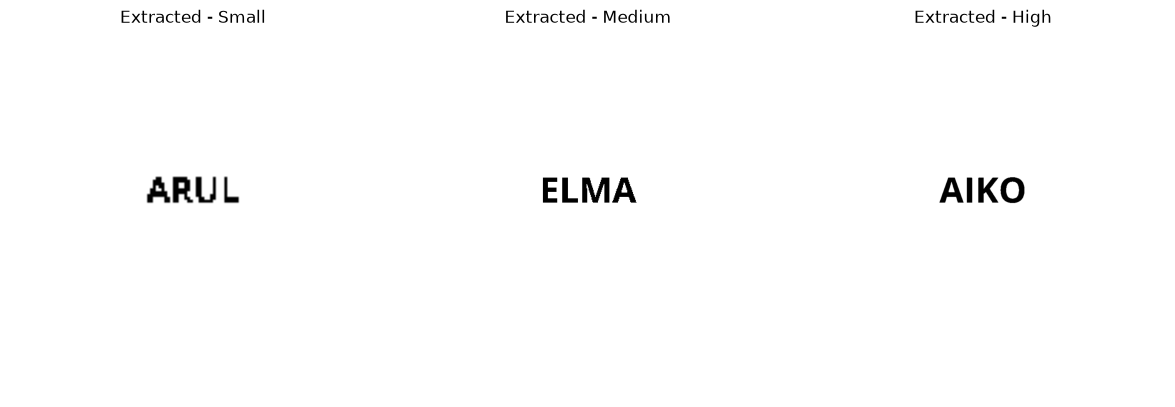

In [32]:
# --- Tampilkan hasil ekstraksi ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, label in zip(
    axes,
    [extracted_small_bw, extracted_medium_bw, extracted_high_bw],
    ["Small", "Medium", "High"]
):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Extracted - {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [33]:
# --- Verifikasi: watermark sebelum embedding == watermark setelah ekstraksi ---
def verify_extraction(original_bit, extracted_bit, label):
    assert original_bit.shape == extracted_bit.shape, \
        f"Shape tidak cocok: asli {original_bit.shape} vs ekstraksi {extracted_bit.shape}"

    total_bit = original_bit.size
    matching_bit = np.sum(original_bit == extracted_bit)
    accuracy = matching_bit / total_bit * 100
    is_identical = np.array_equal(original_bit, extracted_bit)

    print(f"[{label}] Akurasi ekstraksi: {accuracy:.4f}% | Identik 100%? {is_identical}")
    return accuracy, is_identical

print("=== VERIFIKASI EKSTRAKSI WATERMARK ===")
verify_extraction(watermark1_bit_original, extracted_small_bit,  "Small")
verify_extraction(watermark2_bit_original, extracted_medium_bit, "Medium")
verify_extraction(watermark3_bit_original, extracted_high_bit,   "High")

=== VERIFIKASI EKSTRAKSI WATERMARK ===
[Small] Akurasi ekstraksi: 100.0000% | Identik 100%? True
[Medium] Akurasi ekstraksi: 100.0000% | Identik 100%? True
[High] Akurasi ekstraksi: 100.0000% | Identik 100%? True


(np.float64(100.0), True)